# Motor Insurance Pure Premium Modeling using GLM & Tweedie Regression
**Dataset:** French Motor Third-Party Liability (`freMTPL2freq` - OpenML ID: 41214, `freMTPL2sev` - OpenML ID: 41215).
**Observasi:** 678.013 polis kendaraan bermotor Prancis dengan variabel risiko, eksposur, frekuensi klaim (`ClaimNb`), dan total nominal klaim (`ClaimAmount`).

Notebook ini membangun pipeline penetapan tarif premi murni (*Pure Premium*) berbasis metode aktuaria Generalized Linear Models (GLM) dan Tweedie Compound Poisson-Gamma. Seluruh visualisasi diekspor ke folder `images/` dengan resolusi 300 DPI.

### Tujuan Analisis & Pemodelan:
1. **Data Ingestion & Integration**: Menggabungkan dataset frekuensi (`freMTPL2freq`) dan severity (`freMTPL2sev`) berbasis agregasi `IDpol`.
2. **Actuarial Risk Profiling**: Analisis distribusi eksposur, log densitas penduduk, rasio bonus-malus, dan usia pengemudi terhadap tingkat klaim.
3. **Claim Frequency Modeling (Poisson GLM)**: Pemodelan laju klaim per unit eksposur dengan offset $\log(\text{Exposure})$.
4. **Claim Severity Modeling (Gamma GLM)**: Pemodelan rata-rata biaya klaim kondisional untuk polis yang mengalami klaim ($N > 0$).
5. **Pure Premium Synthesis & Tweedie Benchmark**: Penggabungan $\text{Pure Premium} = \mathbb{E}[N] \times \mathbb{E}[S]$ serta perbandingan dengan model langsung Tweedie Regressor ($p \approx 1.5$).
6. **Actuarial Model Evaluation**: Evaluasi performa menggunakan Poisson/Gamma Deviance, Lorenz Curve, Gini Index, dan Double Lift Chart.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import PoissonRegressor, GammaRegressor, TweedieRegressor
from sklearn.metrics import d2_tweedie_score, mean_poisson_deviance, mean_gamma_deviance

os.makedirs('images', exist_ok=True)
os.makedirs('data', exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 15,
    'figure.figsize': (12, 6)
})

print("Konfigurasi pustaka dan visualisasi berhasil diinisialisasi.")

Konfigurasi pustaka dan visualisasi berhasil diinisialisasi.


In [2]:
freq_path = os.path.join('data', 'freMTPL2freq.csv')
sev_path = os.path.join('data', 'freMTPL2sev.csv')

if os.path.exists(freq_path) and os.path.exists(sev_path):
    print("Memuat dataset dari penyimpanan lokal (cache)...\n")
    df_freq = pd.read_csv(freq_path)
    df_sev = pd.read_csv(sev_path)
else:
    print("Mengunduh dataset dari OpenML (freMTPL2freq & freMTPL2sev)...\n")
    df_freq = fetch_openml(data_id=41214, as_frame=True, parser='auto').frame
    df_sev = fetch_openml(data_id=41215, as_frame=True, parser='auto').frame
    df_freq.to_csv(freq_path, index=False)
    df_sev.to_csv(sev_path, index=False)

print(f"Dimensi data frekuensi: {df_freq.shape}")
print(f"Dimensi data severity: {df_sev.shape}")

sev_agg = df_sev.groupby('IDpol').agg(
    ClaimAmountTotal=('ClaimAmount', 'sum'),
    ClaimCountSev=('ClaimAmount', 'count')
).reset_index()

df = pd.merge(df_freq, sev_agg, on='IDpol', how='left')
df['ClaimAmountTotal'] = df['ClaimAmountTotal'].fillna(0.0)
df['ClaimCountSev'] = df['ClaimCountSev'].fillna(0).astype(int)

# Standarisasi aturan aktuaria: pemotongan eksposur > 1.0 tahun dan validasi klaim batas atas
df['Exposure'] = np.clip(df['Exposure'], a_min=0.001, a_max=1.0)
df['ClaimNb'] = np.clip(df['ClaimNb'], a_min=0, a_max=4)
df['PurePremiumEmpirical'] = df['ClaimAmountTotal'] / df['Exposure']

print(f"Total observasi bersih setelah penggabungan: {len(df):,}")
print(f"Persentase polis yang mengajukan klaim: {(df['ClaimAmountTotal'] > 0).mean() * 100:.2f}%")
df.head()

Memuat dataset dari penyimpanan lokal (cache)...



Dimensi data frekuensi: (678013, 12)
Dimensi data severity: (26639, 2)
Total observasi bersih setelah penggabungan: 678,013
Persentase polis yang mengajukan klaim: 3.68%


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmountTotal,ClaimCountSev,PurePremiumEmpirical
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82,0.0,0,0.0
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82,0.0,0,0.0
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22,0.0,0,0.0
3,10.0,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72,0.0,0,0.0
4,11.0,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72,0.0,0,0.0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15216\1258653903.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=claim_by_age, x='DrivAge', y='ClaimFrequency', palette='Blues_r', ax=axes[0, 1])


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15216\1258653903.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=claim_by_bm, x='BonusMalusStr', y='ClaimFrequency', palette='Reds', ax=axes[1, 0])


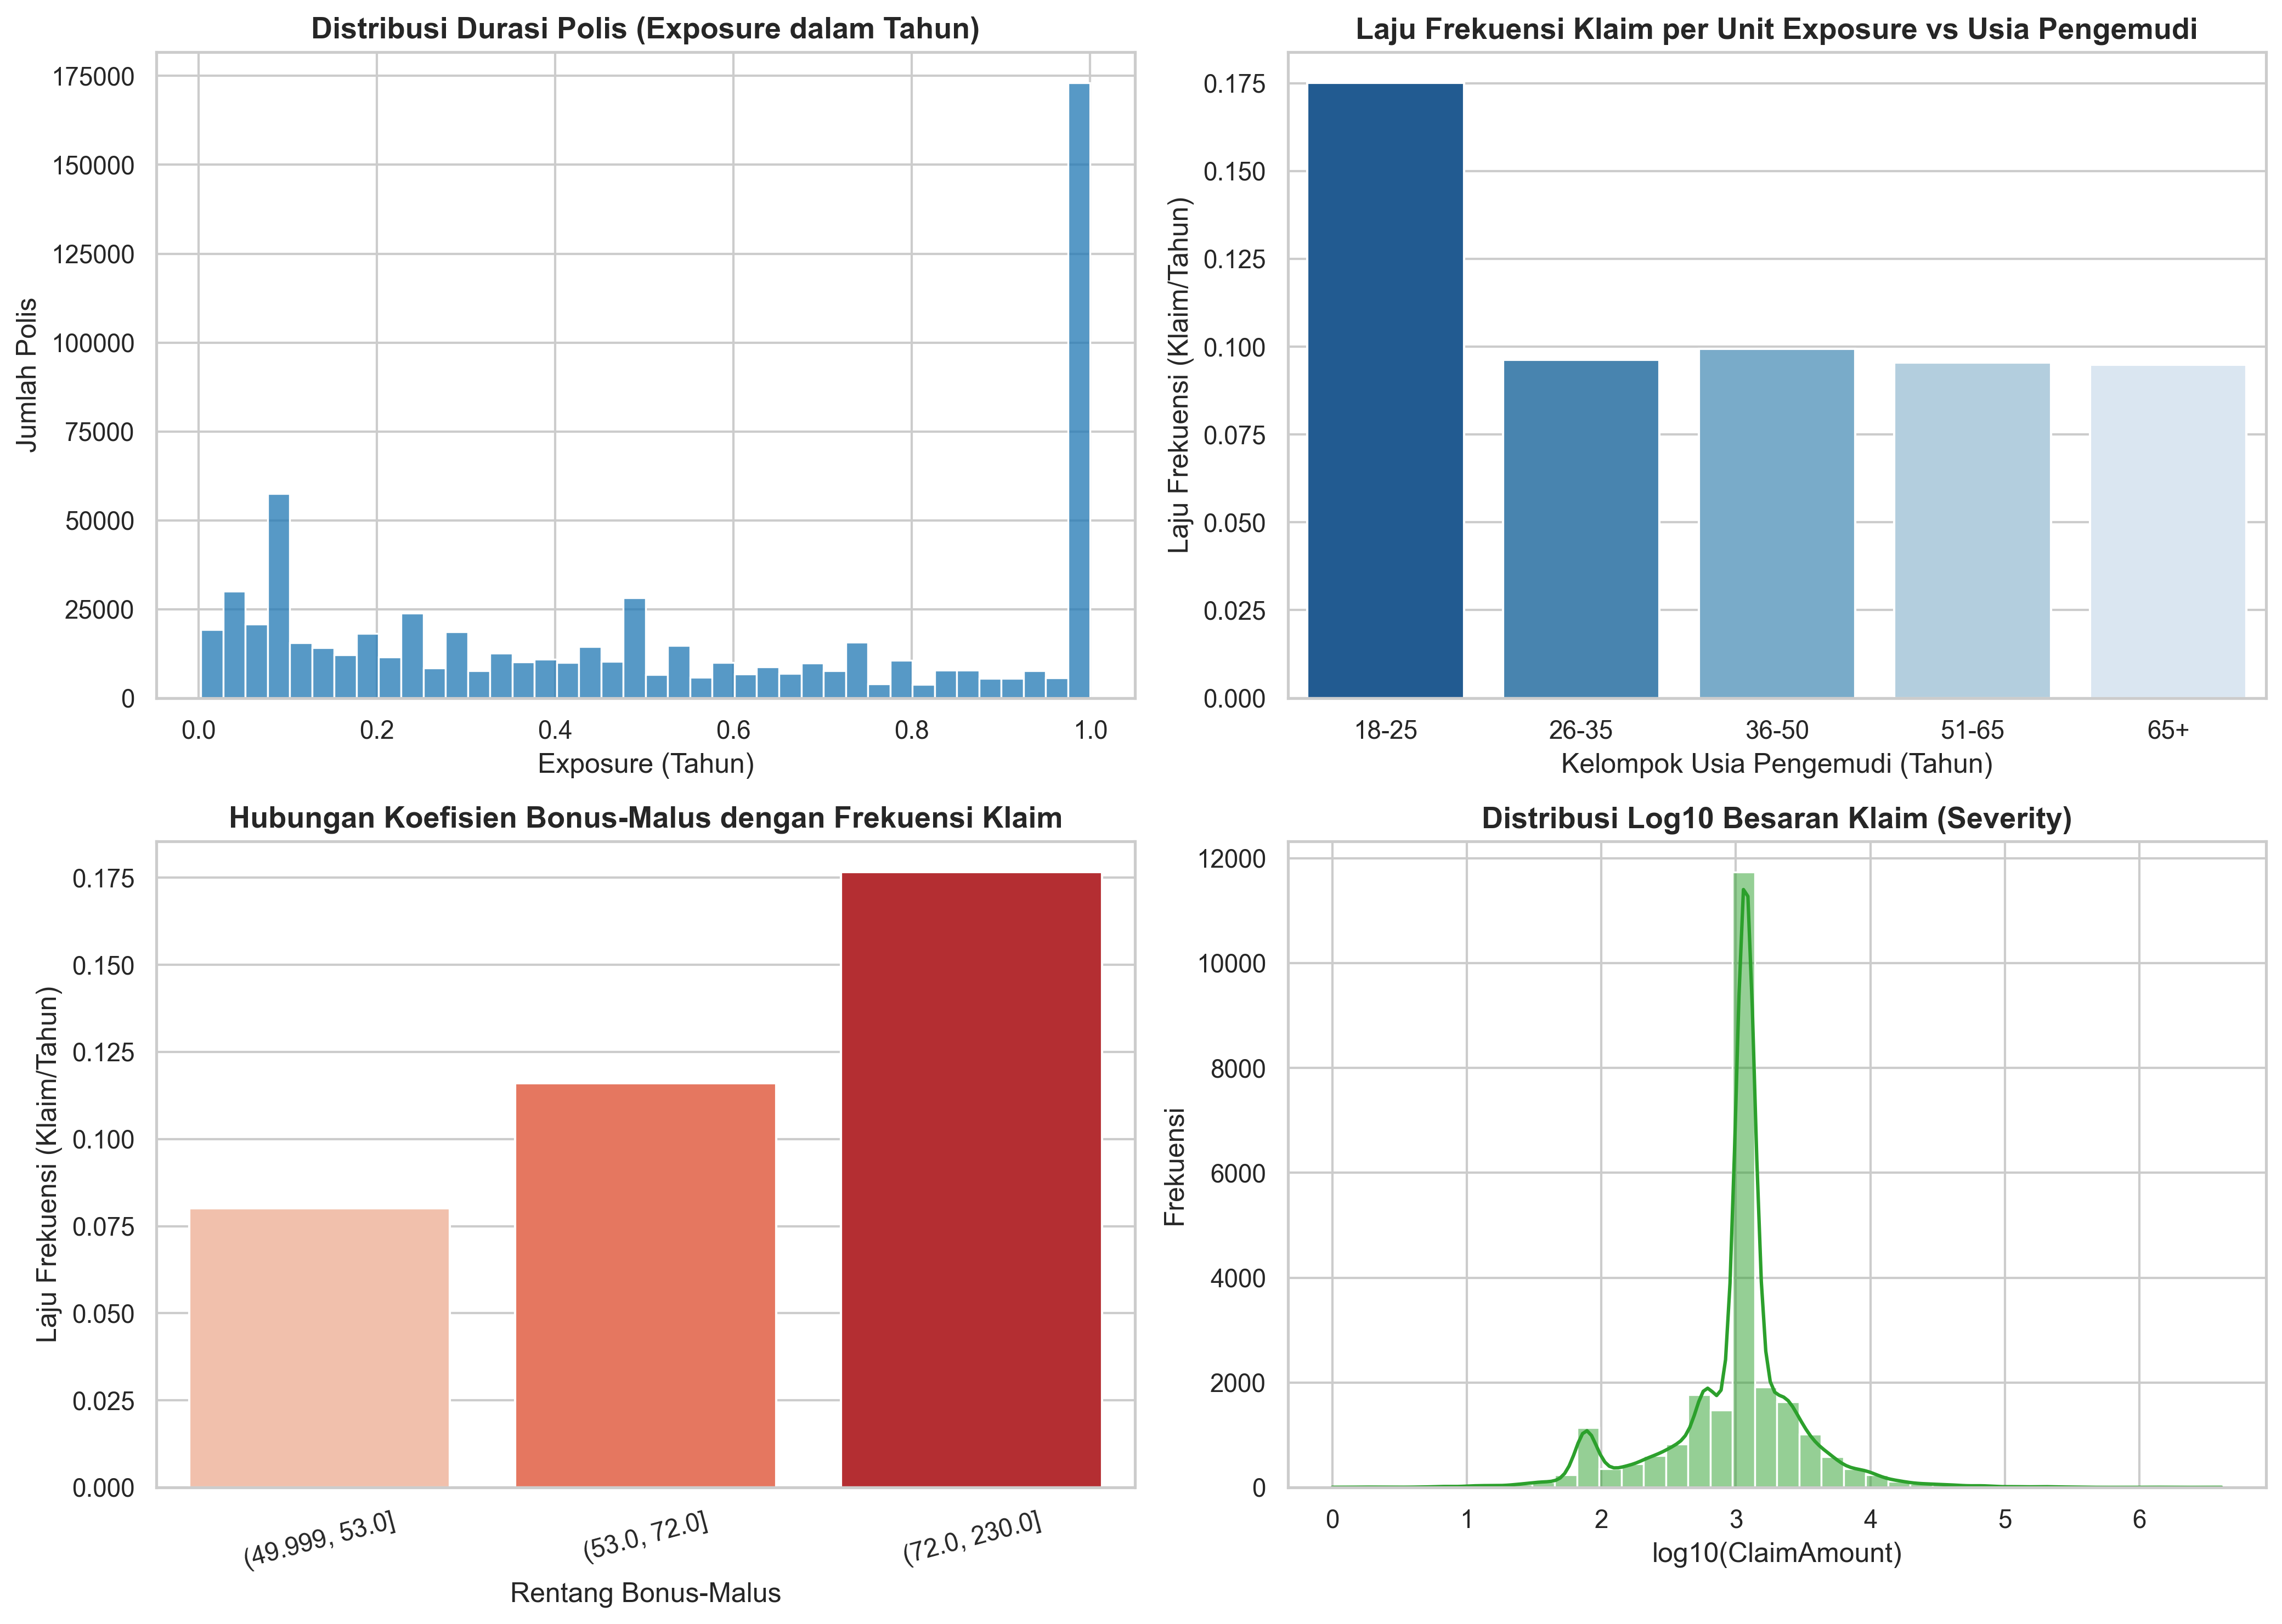

Visualisasi profil risiko EDA berhasil diekspor ke images/actuarial_risk_eda.png


In [3]:
df['LogDensity'] = np.log(df['Density'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribusi Exposure
sns.histplot(df['Exposure'], bins=40, kde=False, color='#1f77b4', ax=axes[0, 0])
axes[0, 0].set_title('Distribusi Durasi Polis (Exposure dalam Tahun)', fontweight='bold')
axes[0, 0].set_xlabel('Exposure (Tahun)')
axes[0, 0].set_ylabel('Jumlah Polis')

# 2. Frekuensi Klaim Relatif per Kelompok Usia Pengemudi
age_bins = pd.cut(df['DrivAge'], bins=[17, 25, 35, 50, 65, 100], labels=['18-25', '26-35', '36-50', '51-65', '65+'])
claim_by_age = df.groupby(age_bins, observed=False).apply(
    lambda g: g['ClaimNb'].sum() / g['Exposure'].sum()
).reset_index(name='ClaimFrequency')

sns.barplot(data=claim_by_age, x='DrivAge', y='ClaimFrequency', palette='Blues_r', ax=axes[0, 1])
axes[0, 1].set_title('Laju Frekuensi Klaim per Unit Exposure vs Usia Pengemudi', fontweight='bold')
axes[0, 1].set_xlabel('Kelompok Usia Pengemudi (Tahun)')
axes[0, 1].set_ylabel('Laju Frekuensi (Klaim/Tahun)')

# 3. Laju Klaim vs Bonus-Malus Rate
bm_cut = pd.qcut(df['BonusMalus'], q=5, duplicates='drop')
claim_by_bm = df.groupby(bm_cut, observed=False).apply(
    lambda g: g['ClaimNb'].sum() / g['Exposure'].sum()
).reset_index(name='ClaimFrequency')
claim_by_bm['BonusMalusStr'] = claim_by_bm['BonusMalus'].astype(str)

sns.barplot(data=claim_by_bm, x='BonusMalusStr', y='ClaimFrequency', palette='Reds', ax=axes[1, 0])
axes[1, 0].set_title('Hubungan Koefisien Bonus-Malus dengan Frekuensi Klaim', fontweight='bold')
axes[1, 0].set_xlabel('Rentang Bonus-Malus')
axes[1, 0].set_ylabel('Laju Frekuensi (Klaim/Tahun)')
axes[1, 0].tick_params(axis='x', rotation=15)

# 4. Distribusi Log Total Klaim Nominal (Severity)
positive_claims = df[df['ClaimAmountTotal'] > 0]['ClaimAmountTotal']
sns.histplot(np.log10(positive_claims), bins=40, kde=True, color='#2ca02c', ax=axes[1, 1])
axes[1, 1].set_title('Distribusi Log10 Besaran Klaim (Severity)', fontweight='bold')
axes[1, 1].set_xlabel('log10(ClaimAmount)')
axes[1, 1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('images/actuarial_risk_eda.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualisasi profil risiko EDA berhasil diekspor ke images/actuarial_risk_eda.png")

In [4]:
# Pembagian Train-Test Split terisolasi (Mencegah Kebocoran Data)
feature_cols = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Region', 'LogDensity']
cat_cols = ['VehBrand', 'VehGas', 'Area', 'Region']
num_cols = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'LogDensity']

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ]
)

preprocessor.fit(df_train[feature_cols])
X_train = preprocessor.transform(df_train[feature_cols])
X_test = preprocessor.transform(df_test[feature_cols])

print(f"Jumlah sampel pelatihan: {len(df_train):,}")
print(f"Jumlah sampel pengujian: {len(df_test):,}")
print(f"Dimensi fitur setelah encoding: {X_train.shape[1]}")

Jumlah sampel pelatihan: 542,410
Jumlah sampel pengujian: 135,603
Dimensi fitur setelah encoding: 42


In [5]:
# 1. Model Frekuensi: Poisson GLM (Laju klaim dengan sample_weight=Exposure)
model_freq = PoissonRegressor(alpha=1e-3, max_iter=300)
model_freq.fit(X_train, df_train['ClaimNb'], sample_weight=df_train['Exposure'])

pred_freq_train = model_freq.predict(X_train)
pred_freq_test = model_freq.predict(X_test)

# 2. Model Severity: Gamma GLM (Hanya dilatih pada data ber-klaim > 0)
mask_sev_train = (df_train['ClaimAmountTotal'] > 0) & (df_train['ClaimNb'] > 0)
mask_sev_test = (df_test['ClaimAmountTotal'] > 0) & (df_test['ClaimNb'] > 0)

X_train_sev = X_train[mask_sev_train]
y_train_sev = df_train.loc[mask_sev_train, 'ClaimAmountTotal'] / df_train.loc[mask_sev_train, 'ClaimNb']
weights_train_sev = df_train.loc[mask_sev_train, 'ClaimNb']

model_sev = GammaRegressor(alpha=1e-2, max_iter=300)
model_sev.fit(X_train_sev, y_train_sev, sample_weight=weights_train_sev)

pred_sev_test = model_sev.predict(X_test)
pure_premium_glm_test = pred_freq_test * pred_sev_test

# 3. Model Pembanding Langsung: Tweedie GLM (p=1.5)
model_tweedie = TweedieRegressor(power=1.5, alpha=1e-3, max_iter=300)
model_tweedie.fit(
    X_train,
    df_train['ClaimAmountTotal'] / df_train['Exposure'],
    sample_weight=df_train['Exposure']
)
pure_premium_tweedie_test = model_tweedie.predict(X_test)

print("Pelatihan model Frequency, Severity, dan Tweedie selesai dieksekusi.")

Pelatihan model Frequency, Severity, dan Tweedie selesai dieksekusi.


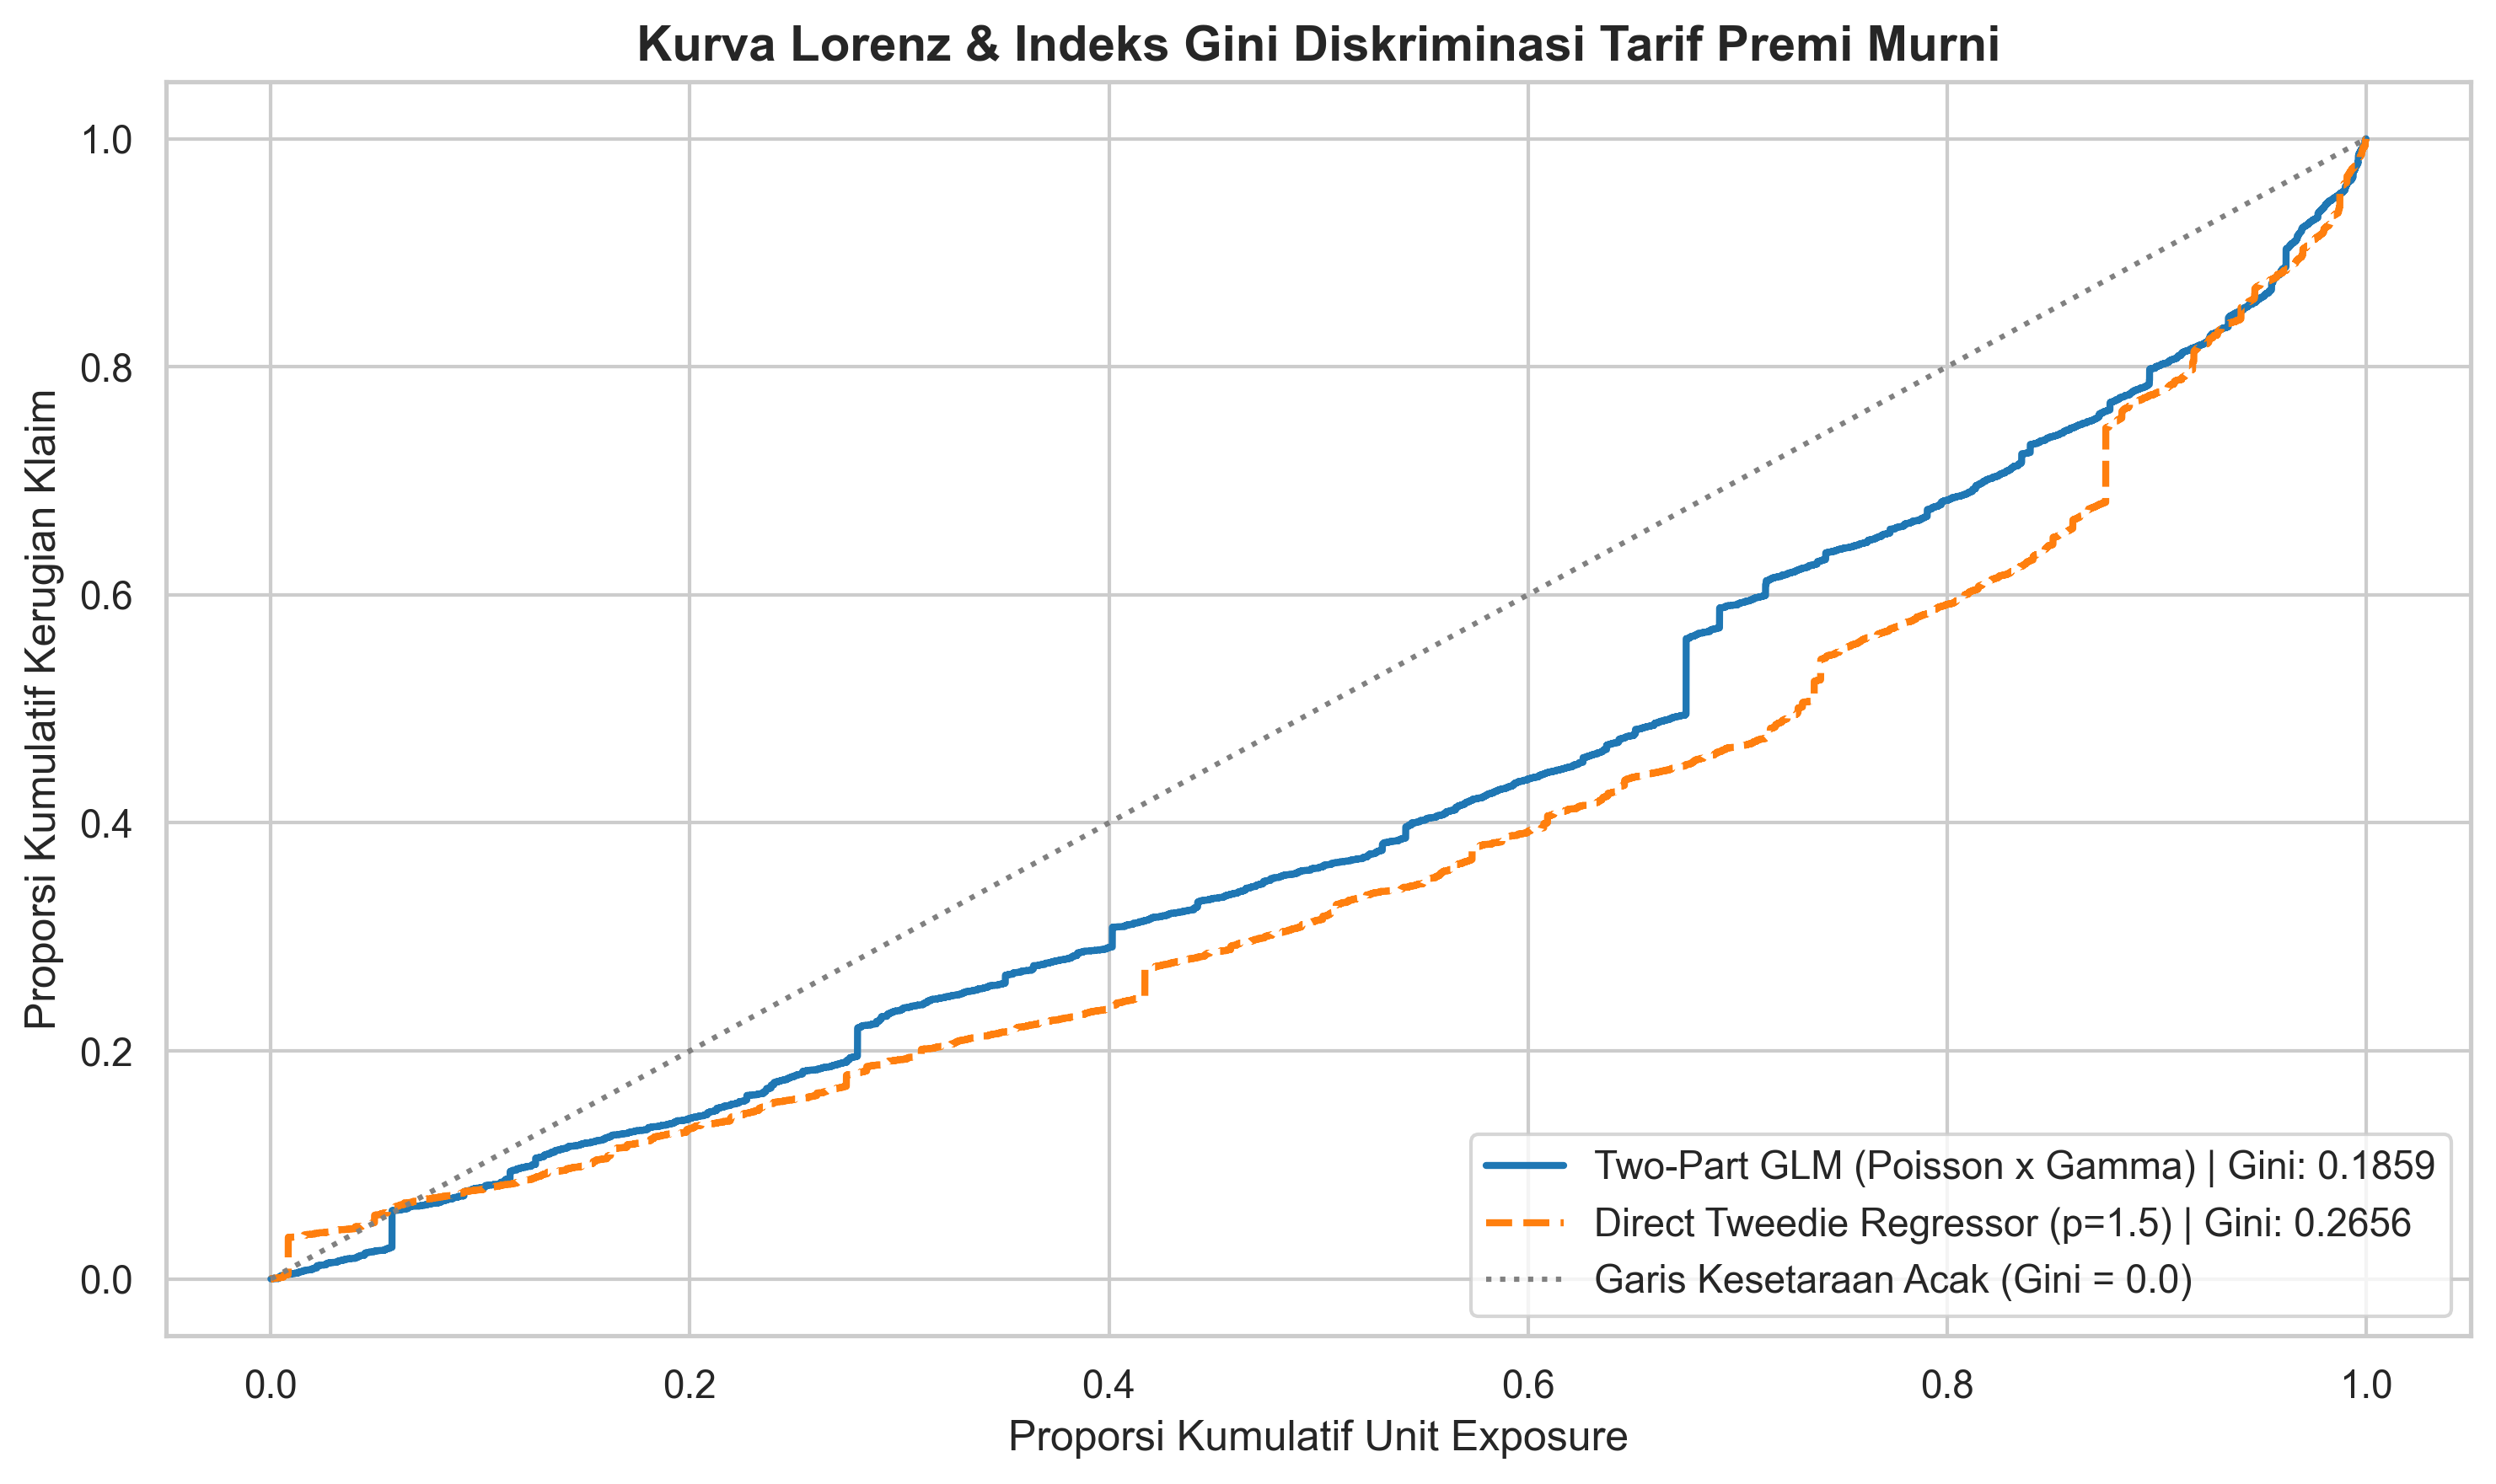

Indeks Gini Two-Part GLM: 0.1859
Indeks Gini Tweedie GLM : 0.2656
Visualisasi kurva Lorenz berhasil diekspor ke images/lorenz_gini_comparison.png


In [6]:
# Evaluasi Aktuaria: Kurva Lorenz dan Gini Index untuk Pricing Discrimination
def calculate_lorenz_gini(y_true, y_pred, exposure):
    df_eval = pd.DataFrame({'true': y_true, 'pred': y_pred, 'exposure': exposure})
    df_eval = df_eval.sort_values('pred').reset_index(drop=True)
    
    cum_exposure = np.cumsum(df_eval['exposure']) / np.sum(df_eval['exposure'])
    cum_losses = np.cumsum(df_eval['true']) / np.sum(df_eval['true'])
    
    # Gini Coefficient = 1 - 2 * AUC(Lorenz) [disesuaikan terhadap trapesium]
    area = np.sum((cum_exposure[1:].values - cum_exposure[:-1].values) * (cum_losses[1:].values + cum_losses[:-1].values) / 2.0)
    gini = 1.0 - 2.0 * area
    return cum_exposure, cum_losses, gini

exp_glm, loss_glm, gini_glm = calculate_lorenz_gini(
    df_test['ClaimAmountTotal'].values,
    pure_premium_glm_test,
    df_test['Exposure'].values
)

exp_twd, loss_twd, gini_twd = calculate_lorenz_gini(
    df_test['ClaimAmountTotal'].values,
    pure_premium_tweedie_test,
    df_test['Exposure'].values
)

plt.figure(figsize=(10, 6))
plt.plot(exp_glm, loss_glm, label=f'Two-Part GLM (Poisson x Gamma) | Gini: {gini_glm:.4f}', color='#1f77b4', lw=2)
plt.plot(exp_twd, loss_twd, label=f'Direct Tweedie Regressor (p=1.5) | Gini: {gini_twd:.4f}', color='#ff7f0e', lw=2, linestyle='--')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Garis Kesetaraan Acak (Gini = 0.0)')

plt.title('Kurva Lorenz & Indeks Gini Diskriminasi Tarif Premi Murni', fontsize=14, fontweight='bold')
plt.xlabel('Proporsi Kumulatif Unit Exposure')
plt.ylabel('Proporsi Kumulatif Kerugian Klaim')
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig('images/lorenz_gini_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Indeks Gini Two-Part GLM: {gini_glm:.4f}")
print(f"Indeks Gini Tweedie GLM : {gini_twd:.4f}")
print("Visualisasi kurva Lorenz berhasil diekspor ke images/lorenz_gini_comparison.png")